##**Separation**
Separation is a fairness criterion requiring that a score R(X) satisfies equal error rates accros sensitive groups A at threshold τ. Formally, it requires that the true positive rate (TPR) and false negative rate (FNR) are equal across all groups.

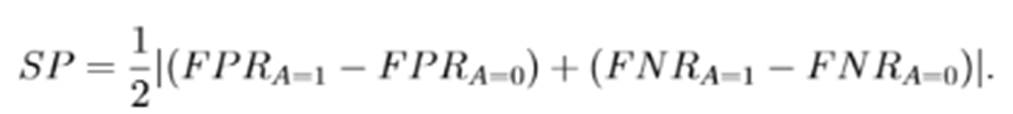

In [1]:
import pandas as pd

df= pd.read_csv("/content/freddie_hmda_landmark.csv")

#**1**
Compute SP for each landamrk s of the dynamic model and a single SP for the static model replicated flat across all s

s=  6 | TPR White=0.128  Black=0.361  gap=0.233 | FPR White=0.024  Black=0.044  gap=0.020
s= 12 | TPR White=0.167  Black=0.158  gap=0.009 | FPR White=0.025  Black=0.047  gap=0.022
s= 18 | TPR White=0.036  Black=0.100  gap=0.064 | FPR White=0.020  Black=0.026  gap=0.006
s= 24 | TPR White=0.038  Black=0.143  gap=0.104 | FPR White=0.009  Black=0.027  gap=0.018
s= 36 | TPR White=0.000  Black=0.000  gap=0.000 | FPR White=0.006  Black=0.019  gap=0.013
s= 48 | TPR White=0.000  Black=0.000  gap=0.000 | FPR White=0.000  Black=0.000  gap=0.000
s= 60 | TPR White=0.000  Black=0.000  gap=0.000 | FPR White=0.000  Black=0.000  gap=0.000

  Landmark s |       SP
-------------------------
           6 |   0.1066
          12 |   0.0156
          18 |   0.0293
          24 |   0.0432
          36 |   0.0065
          48 |   0.0000
          60 |   0.0000


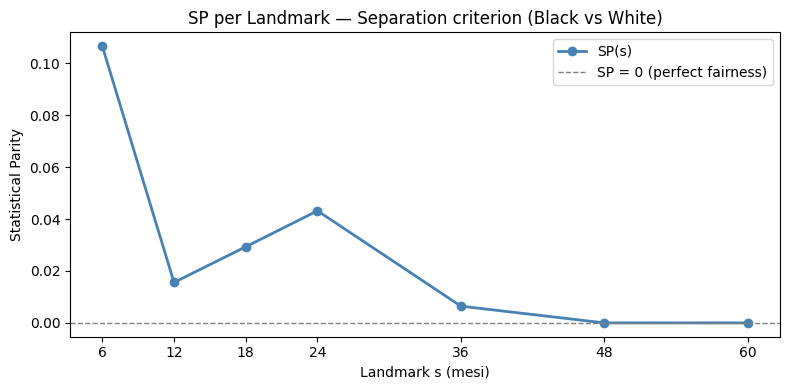

In [10]:
from sklearn.metrics import confusion_matrix



LANDMARKS = [6, 12, 18, 24, 36, 48, 60]
GROUPS = ["White", "Black"]

results = {}

for s in df["landmark_s"].unique():
    sub = df[df["landmark_s"] == s]
    results[s] = {}

    for group in GROUPS:
        g = sub[sub["race"] == group]
        # Handle cases where a group might have only one class present
        if g["default_12m"].nunique() == 0 or g["predicted_label"].nunique() == 0:
            # Let's assign 0s to avoid the ValueError
            tn, fp, fn, tp = 0, 0, 0, 0
        else:
            cm = confusion_matrix(
                g["default_12m"],
                g["predicted_label"],
                labels=[0, 1]
            ).ravel()
            tn, fp, fn, tp = cm


        tpr_denominator = tp + fn
        fpr_denominator = fp + tn

        results[s][group] = {
            "TPR": tp / tpr_denominator if tpr_denominator > 0 else 0,
            "FPR": fp / fpr_denominator if fpr_denominator > 0 else 0,
            "TP": int(tp), "FP": int(fp),
            "TN": int(tn), "FN": int(fn)
        }

for s, groups in results.items():
    # Ensure both 'White' and 'Black' groups exist for current landmark s
    if "White" in groups and "Black" in groups:
        tpr_gap = abs(groups["Black"]["TPR"] - groups["White"]["TPR"])
        fpr_gap = abs(groups["Black"]["FPR"] - groups["White"]["FPR"])
        print(f"s={s:>3} | TPR White={groups['White']['TPR']:.3f}  Black={groups['Black']['TPR']:.3f}  gap={tpr_gap:.3f} | "
              f"FPR White={groups['White']['FPR']:.3f}  Black={groups['Black']['FPR']:.3f}  gap={fpr_gap:.3f}")
    else:
        print(f"s={s:>3} | Not enough data for both 'White' and 'Black' groups to compute gap.")

import matplotlib.pyplot as plt
print("")

# ── SP per ogni landmark ──────────────────────────────────────────────────────
# SP = 0.5 * |(FPR_Black - FPR_White) + (FNR_Black - FNR_White)|
# FNR = 1 - TPR

sp_by_landmark = {}

for s, groups in results.items():
    if "White" in groups and "Black" in groups:
        fpr_diff = groups["Black"]["FPR"] - groups["White"]["FPR"]
        fnr_diff = (1 - groups["Black"]["TPR"]) - (1 - groups["White"]["TPR"])
        sp = 0.5 * abs(fpr_diff + fnr_diff)
        sp_by_landmark[s] = sp

# Stampa
print(f"{'Landmark s':>12} | {'SP':>8}")
print("-" * 25)
for s in sorted(sp_by_landmark):
    print(f"{s:>12} | {sp_by_landmark[s]:>8.4f}")

# ── Curva SP per landmark ─────────────────────────────────────────────────────
landmarks_sorted = sorted(sp_by_landmark.keys())
sp_values = [sp_by_landmark[s] for s in landmarks_sorted]

plt.figure(figsize=(8, 4))
plt.plot(landmarks_sorted, sp_values, marker="o", linewidth=2, color="steelblue", label="SP(s)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1, label="SP = 0 (perfect fairness)")
plt.xlabel("Landmark s (mesi)")
plt.ylabel("Statistical Parity")
plt.title("SP per Landmark — Separation criterion (Black vs White)")
plt.xticks(landmarks_sorted)
plt.legend()
plt.tight_layout()
plt.show()



---

#**2**
New formulation of SP using TPR(T)-FPR(T) defined for survival analysisi in "A tutorial on Evaluation the Time-Varying Discrimination Accuracy of Surivival Models Used in Dynamic Decision Making". line vs curve.

Da github: https://github.com/aasthaa/meanrankROC_package/blob/master/dynamicTP.q

In [17]:
import numpy as np
from typing import Optional

def pcval(y_j, Y_db):
    """P(Y_db < y_j) — strict inequality, empirical CDF."""
    def ecdf_strict_less(y_j, Y_db):
        return np.array([np.mean(Y_db < val) for val in y_j])
    return ecdf_strict_less(y_j, Y_db)

def roct(y_j, Y_db, t):
  """Costruisce la ROC al tempo t: trasforma i pcvals in 1 - pcval (= FPR) e calcola la proporzione ≤ t"""
    pcvals = pcval(y_j, Y_db)
    transformed = 1 - pcvals
    F_pl = np.mean(transformed <= t)
    return F_pl



def dynamicTP(p: float,
              survival_time: np.ndarray,
              survival_status: np.ndarray,
              marker: np.ndarray,
              start: Optional[np.ndarray] = None):
    """
    INPUT:  survival_time   = follow-up time
            survival_status = indicator of observed event (1=event, 0=censored)
            marker          = quantitative marker (score)
            start           = start time for interval (optional, default 0)

    RETURN: dict with keys:
              time       = unique event times
              mean_rank  = mean rank of case within risk set (TPR at threshold p)
              nControls  = number of controls at each time
              nCases     = number of cases at each time
    """
    if start is None:
        start = np.zeros(len(survival_time))

    # Drop missing values
    keep = (~np.isnan(survival_time) &
            ~np.isnan(survival_status) &
            ~np.isnan(marker) &
            ~np.isnan(start))
    survival_time   = survival_time[keep]
    survival_status = survival_status[keep]
    marker          = marker[keep]
    start           = start[keep]

    # Unique event times, sorted
    utimes = np.unique(survival_time[survival_status == 1])
    #Ai mesi senza default non c'è nessun case da classificare, quindi TPR non è definita.
    #La funzione calcola la discriminazione del modello nei momenti in cui qualcuno effettivamente
    #defaulta — se a t=15 non defaulta nessuno, non c'è niente da valutare lì.
    utimes = np.sort(utimes)

    nonparm_auc = np.full(len(utimes), np.nan)
    n_controls  = np.zeros(len(utimes))
    n_cases     = np.zeros(len(utimes))
    the_marker  = marker

    for j, t in enumerate(utimes):
        # Cases: events exactly at time t
        dead_guys   = the_marker[(survival_time == t) & (survival_status == 1)]
        # Controls: started before t and still alive after t
        is_started  = start < t
        control_set = the_marker[is_started & (survival_time > t)]

        set_size       = len(control_set)
        ndead          = len(dead_guys)
        n_controls[j]  = set_size
        n_cases[j]     = ndead

        if set_size == 0:
            nonparm_auc[j] = np.nan
            continue

        if ndead == 1:
            rank = np.sum(dead_guys[0] > control_set) / set_size
            nonparm_auc[j] = float(rank > (1 - p))
        else:
            mean_rank = 0.0
            for k in range(ndead):
                rank = np.sum(dead_guys[k] > control_set) / set_size
                this_rank  = float(rank > (1 - p))
                mean_rank += this_rank / ndead
            nonparm_auc[j] = mean_rank

    return {
        "time"      : utimes,
        "mean_rank" : nonparm_auc,
        "nControls" : n_controls,
        "nCases"    : n_cases,
    }

df_long = pd.read_csv("freddie_hmda_long_monthly.csv")

# Per un gruppo alla volta
g = df_long[df_long["race"] == "Black"]

# Per ogni loan, prendi l'ultima riga (= tempo di uscita + status)
last_obs = g.sort_values("loan_age_months").groupby("loan_id").last().reset_index()

result = dynamicTP(
    p               = 0.5,
    survival_time   = last_obs["loan_age_months"].values,
    survival_status = last_obs["default_event"].values,
    marker          = last_obs["score"].values,
    start           = np.zeros(len(last_obs))   # tutti partono da 0
)

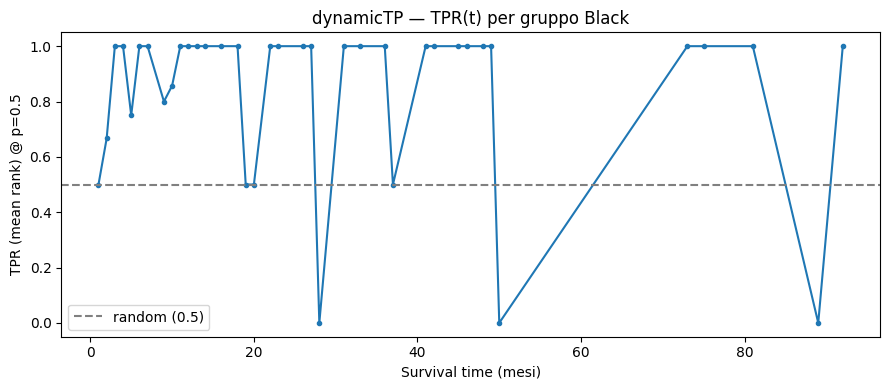

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(result["time"], result["mean_rank"], marker="o", markersize=3, linewidth=1.5)
plt.axhline(0.5, color="gray", linestyle="--", label="random (0.5)")
plt.xlabel("Survival time (mesi)")
plt.ylabel("TPR (mean rank) @ p=0.5")
plt.title("dynamicTP — TPR(t) per gruppo Black")
plt.legend()
plt.tight_layout()
plt.show()

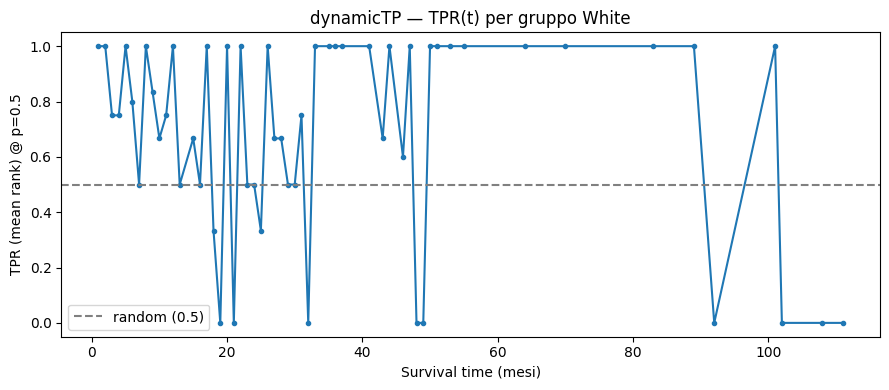

In [20]:
# Per un gruppo alla volta
g = df_long[df_long["race"] == "White"]

# Per ogni loan, prendi l'ultima riga (= tempo di uscita + status)
last_obs = g.sort_values("loan_age_months").groupby("loan_id").last().reset_index()

result = dynamicTP(
    p               = 0.5,
    survival_time   = last_obs["loan_age_months"].values,
    survival_status = last_obs["default_event"].values,
    marker          = last_obs["score"].values,
    start           = np.zeros(len(last_obs))   # tutti partono da 0
)
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(result["time"], result["mean_rank"], marker="o", markersize=3, linewidth=1.5)
plt.axhline(0.5, color="gray", linestyle="--", label="random (0.5)")
plt.xlabel("Survival time (mesi)")
plt.ylabel("TPR (mean rank) @ p=0.5")
plt.title("dynamicTP — TPR(t) per gruppo White")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
def dynamicFP(p: float,
              survival_time: np.ndarray,
              survival_status: np.ndarray,
              marker: np.ndarray,
              start: Optional[np.ndarray] = None):

    if start is None:
        start = np.zeros(len(survival_time))

    keep = (~np.isnan(survival_time) &
            ~np.isnan(survival_status) &
            ~np.isnan(marker) &
            ~np.isnan(start))
    survival_time   = survival_time[keep]
    survival_status = survival_status[keep]
    marker          = marker[keep]
    start           = start[keep]

    utimes = np.unique(survival_time[survival_status == 1])
    utimes = np.sort(utimes)

    nonparm_fpr = np.full(len(utimes), np.nan)
    n_controls  = np.zeros(len(utimes))
    n_cases     = np.zeros(len(utimes))

    for j, t in enumerate(utimes):
        # Cases: defaultano esattamente a t
        dead_guys   = marker[(survival_time == t) & (survival_status == 1)]
        is_started  = start < t
        control_set = marker[is_started & (survival_time > t)]

        set_size = len(control_set)
        ndead    = len(dead_guys)
        n_controls[j] = set_size
        n_cases[j]    = ndead

        if set_size == 0 or ndead == 0:
            nonparm_fpr[j] = np.nan
            continue

        # Per ogni control, verifica se il suo score supera
        # almeno (1-p) dei cases → falso positivo
        mean_fp = 0.0
        for ctrl_score in control_set:
            rank = np.sum(ctrl_score > dead_guys) / ndead
            mean_fp += float(rank > (1 - p)) / set_size

        nonparm_fpr[j] = mean_fp

    return {
        "time"     : utimes,
        "mean_fp"  : nonparm_fpr,
        "nControls": n_controls,
        "nCases"   : n_cases,
    }


"""-------------------------------------------------------------------------------------"""
# Per un gruppo alla volta
g = df_long[df_long["race"] == "Black"]

# Per ogni loan, prendi l'ultima riga (= tempo di uscita + status)
last_obs = g.sort_values("loan_age_months").groupby("loan_id").last().reset_index()



tpr_black =  dynamicTP(
    p               = 0.5,
    survival_time   = last_obs["loan_age_months"].values,
    survival_status = last_obs["default_event"].values,
    marker          = last_obs["score"].values,
    start           = np.zeros(len(last_obs))   # tutti partono da 0
)

fpr_black = dynamicFP(
    p               = 0.5,
    survival_time   = last_obs["loan_age_months"].values,
    survival_status = last_obs["default_event"].values,
    marker          = last_obs["score"].values,
    start           = np.zeros(len(last_obs))   # tutti partono da 0
)


g = df_long[df_long["race"] == "White"]

# Per ogni loan, prendi l'ultima riga (= tempo di uscita + status)
last_obs = g.sort_values("loan_age_months").groupby("loan_id").last().reset_index()


tpr_white = dynamicTP(
    p               = 0.5,
    survival_time   = last_obs["loan_age_months"].values,
    survival_status = last_obs["default_event"].values,
    marker          = last_obs["score"].values,
    start           = np.zeros(len(last_obs))   # tutti partono da 0
)
fpr_white = dynamicFP(
    p               = 0.5,
    survival_time   = last_obs["loan_age_months"].values,
    survival_status = last_obs["default_event"].values,
    marker          = last_obs["score"].values,
    start           = np.zeros(len(last_obs))   # tutti partono da 0
)

common_times = np.intersect1d(tpr_black["time"], tpr_white["time"])

idx_b = np.isin(tpr_black["time"], common_times)
idx_w = np.isin(tpr_white["time"], common_times)

tpr_gap = tpr_black["mean_rank"][idx_b] - tpr_white["mean_rank"][idx_w]
fpr_gap = fpr_black["mean_fp"][idx_b]   - fpr_white["mean_fp"][idx_w]

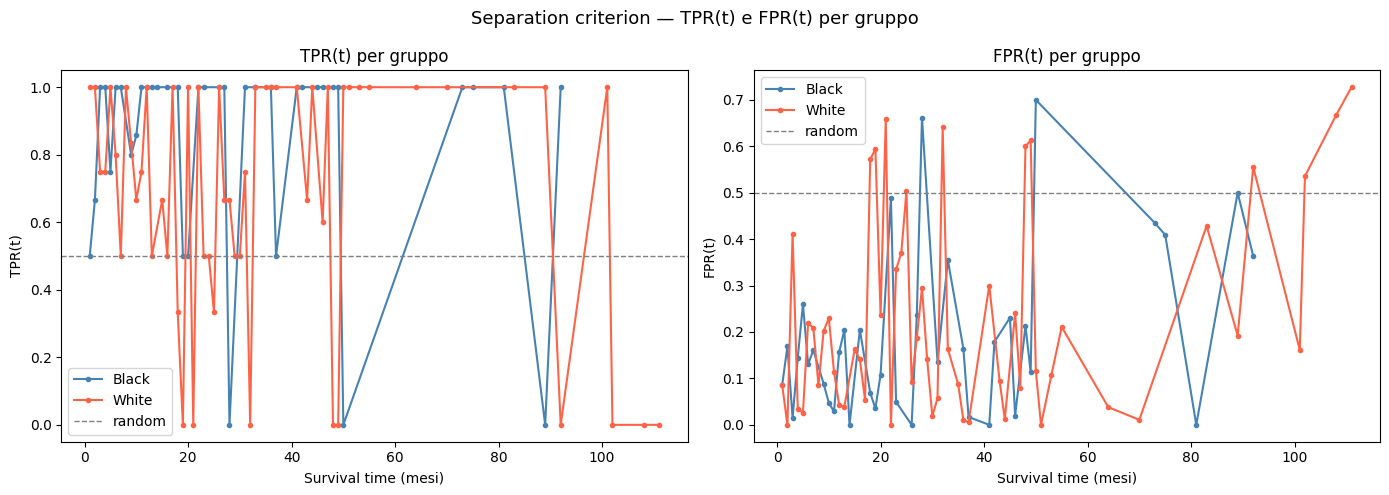

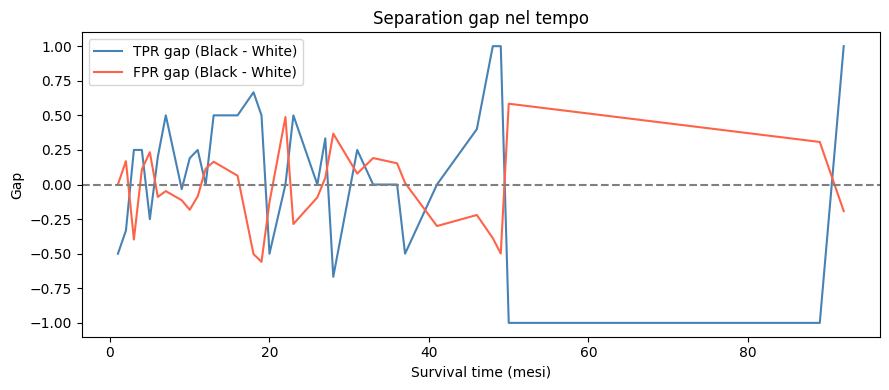

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── TPR(t) ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(tpr_black["time"], tpr_black["mean_rank"], marker="o", markersize=3,
        linewidth=1.5, color="steelblue", label="Black")
ax.plot(tpr_white["time"], tpr_white["mean_rank"], marker="o", markersize=3,
        linewidth=1.5, color="tomato", label="White")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random")
ax.set_xlabel("Survival time (mesi)")
ax.set_ylabel("TPR(t)")
ax.set_title("TPR(t) per gruppo")
ax.legend()

# ── FPR(t) ────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(fpr_black["time"], fpr_black["mean_fp"], marker="o", markersize=3,
        linewidth=1.5, color="steelblue", label="Black")
ax.plot(fpr_white["time"], fpr_white["mean_fp"], marker="o", markersize=3,
        linewidth=1.5, color="tomato", label="White")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random")
ax.set_xlabel("Survival time (mesi)")
ax.set_ylabel("FPR(t)")
ax.set_title("FPR(t) per gruppo")
ax.legend()

plt.suptitle("Separation criterion — TPR(t) e FPR(t) per gruppo", fontsize=13)
plt.tight_layout()
plt.show()

# Allinea i tempi comuni tra i due gruppi
common_times = np.intersect1d(tpr_black["time"], tpr_white["time"])

idx_b = np.isin(tpr_black["time"], common_times)
idx_w = np.isin(tpr_white["time"], common_times)

tpr_gap = tpr_black["mean_rank"][idx_b] - tpr_white["mean_rank"][idx_w]
fpr_gap = fpr_black["mean_fp"][idx_b]   - fpr_white["mean_fp"][idx_w]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(common_times, tpr_gap, label="TPR gap (Black - White)", color="steelblue")
ax.plot(common_times, fpr_gap, label="FPR gap (Black - White)", color="tomato")
ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("Survival time (mesi)")
ax.set_ylabel("Gap")
ax.set_title("Separation gap nel tempo")
ax.legend()
plt.tight_layout()
plt.show()

Average SP(t): 0.2967


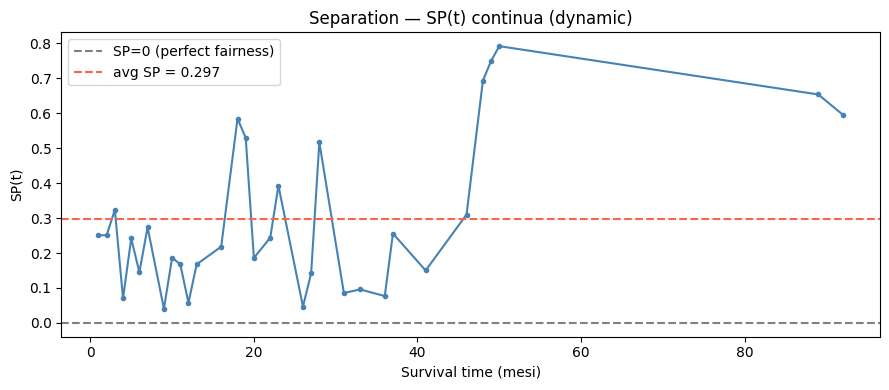

In [25]:
# SP(t) = 0.5 * |FPR_gap(t) + FNR_gap(t)|
# FNR(t) = 1 - TPR(t)

fnr_gap = -tpr_gap  # FNR_black - FNR_white = -(TPR_black - TPR_white)

sp_t = 0.5 * np.abs(fpr_gap + fnr_gap)

# Average SP sulla curva (equivalente alla adTPR/adFPR ma continua)
avg_sp = np.mean(sp_t)
print(f"Average SP(t): {avg_sp:.4f}")
plt.figure(figsize=(9, 4))
plt.plot(common_times, sp_t, marker="o", markersize=3, linewidth=1.5, color="steelblue")
plt.axhline(0, color="gray", linestyle="--", label="SP=0 (perfect fairness)")
plt.axhline(avg_sp, color="tomato", linestyle="--", label=f"avg SP = {avg_sp:.3f}")
plt.xlabel("Survival time (mesi)")
plt.ylabel("SP(t)")
plt.title("Separation — SP(t) continua (dynamic)")
plt.legend()
plt.tight_layout()
plt.show()



---

#**3**
Time-averaged SP: this formualtion measures time-dependent and conditionally adjusted dispariies averaging the worst-case group diffrences at each time step.
(Fairness in Survival Analysis: A novel Conditional Mutual Information Augmentation Approach (2025))



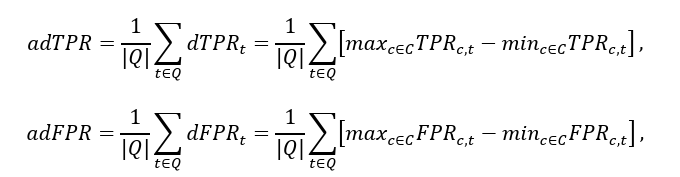

In [13]:
from pandas.core.arrays.period import dt64arr_to_periodarr
from sklearn.metrics import confusion_matrix



LANDMARKS = [6, 12, 18, 24, 36, 48, 60]
GROUPS = ["White", "Black"]

results = {}

for s in df["landmark_s"].unique():
    sub = df[df["landmark_s"] == s]
    results[s] = {}

    for group in GROUPS:
        g = sub[sub["race"] == group]
        # Handle cases where a group might have only one class present
        if g["default_12m"].nunique() == 0 or g["predicted_label"].nunique() == 0:
            # Let's assign 0s to avoid the ValueError
            tn, fp, fn, tp = 0, 0, 0, 0
        else:
            cm = confusion_matrix(
                g["default_12m"],
                g["predicted_label"],
                labels=[0, 1]
            ).ravel()
            tn, fp, fn, tp = cm


        tpr_denominator = tp + fn
        fpr_denominator = fp + tn

        results[s][group] = {
            "TPR": tp / tpr_denominator if tpr_denominator > 0 else 0,
            "FPR": fp / fpr_denominator if fpr_denominator > 0 else 0,
            "TP": int(tp), "FP": int(fp),
            "TN": int(tn), "FN": int(fn)
        }

for s, groups in results.items():
    # Ensure both 'White' and 'Black' groups exist for current landmark s
    if "White" in groups and "Black" in groups:
        tpr_gap = abs(groups["Black"]["TPR"] - groups["White"]["TPR"])
        fpr_gap = abs(groups["Black"]["FPR"] - groups["White"]["FPR"])
        print(f"s={s:>3} | TPR White={groups['White']['TPR']:.3f}  Black={groups['Black']['TPR']:.3f}  gap={tpr_gap:.3f} | "
              f"FPR White={groups['White']['FPR']:.3f}  Black={groups['Black']['FPR']:.3f}  gap={fpr_gap:.3f}")
    else:
        print(f"s={s:>3} | Not enough data for both 'White' and 'Black' groups to compute gap.")

import matplotlib.pyplot as plt
print("")



sp_by_landmark = {}

for s, groups in results.items():
    if "White" in groups and "Black" in groups:
        max_fpr = max(groups["Black"]["FPR"], groups["White"]["FPR"])
        max_tpr = max(groups["Black"]["TPR"], groups["White"]["TPR"])
        min_fpr = min(groups["Black"]["FPR"], groups["White"]["FPR"])
        min_tpr = min(groups["Black"]["TPR"], groups["White"]["TPR"])

        dTPR=max_tpr-min_tpr
        dFPR=max_fpr-min_fpr

        sp_by_landmark[s] = {'dTPR': dTPR, 'dFPR': dFPR}

adTPR = sum(sp_by_landmark[s]['dTPR'] for s in sp_by_landmark)/ len(sp_by_landmark)
adFPR = sum(sp_by_landmark[s]['dFPR'] for s in sp_by_landmark)/ len(sp_by_landmark)
print( f"The averaged maximum difference of the true positive rate (adTPR) is {adTPR} and the false positive rate (adFPR) is {adFPR}")
# Smaller adTPR and adFPR indicates better EO fairness.
#In the case of static no averaged among time

s=  6 | TPR White=0.128  Black=0.361  gap=0.233 | FPR White=0.024  Black=0.044  gap=0.020
s= 12 | TPR White=0.167  Black=0.158  gap=0.009 | FPR White=0.025  Black=0.047  gap=0.022
s= 18 | TPR White=0.036  Black=0.100  gap=0.064 | FPR White=0.020  Black=0.026  gap=0.006
s= 24 | TPR White=0.038  Black=0.143  gap=0.104 | FPR White=0.009  Black=0.027  gap=0.018
s= 36 | TPR White=0.000  Black=0.000  gap=0.000 | FPR White=0.006  Black=0.019  gap=0.013
s= 48 | TPR White=0.000  Black=0.000  gap=0.000 | FPR White=0.000  Black=0.000  gap=0.000
s= 60 | TPR White=0.000  Black=0.000  gap=0.000 | FPR White=0.000  Black=0.000  gap=0.000

The averaged maximum difference of the true positive rate (adTPR) is 0.058700683592700864 and the false positive rate (adFPR) is 0.01131396446452319
